# Notebook to perform HieraType on CosMX RNA Data

# TODO
- ...

## Instructions

- 

## Imports

In [78]:
# Load Packages
library(Seurat)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(gtools)
library(tibble)
library(scPearsonPCA)
library(fs)
library(InSituCor)
library(pheatmap)
library(grid)
library(ComplexHeatmap)
library(viridis)
library(circlize)
library(HieraType)
library(mvtnorm)

In [79]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [80]:
# Define directories
seu_file_path <- file.path("../outputs/TMA18/seurat_objects/annotated_object_TMA18_louvain_final.RDS")
out_dir <- "../outputs" # Folder for outputs
study_name <- "TMA18"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "HieraType")
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

Define Parameters

In [ ]:
ASSAY_NAME <- "RNA"
sdimx_col   <- "x_slide_mm"
sdimy_col   <- "y_slide_mm"
study_id_col <- "study_id"
region_col  <- "region"
annotation_col <- "final_annotation"
cell_id_col <- "cell_ID_new"
# annotation_col <- "broad_annotation"

# HieraType / clustering parameters
graph_slot  <- "scpearson_graph_nobatch"            # Seurat Graph slot holding the NN adjacency matrix
cluster_col <- "scpearson_clusters_nobatch_res1.2"  # Louvain cluster column in metadata

# Tag used to namespace all output files — change when re-running with different params
run_tag <- paste0(study_name, "_", cluster_col)

# Subset
subset <- FALSE

Loading Seurat object

In [82]:
# Load Seurat object
seu <- readRDS(seu_file_path)

In [83]:
# colnames(seu@meta.data)
head(seu@meta.data, n=5)

,fov,Area,AspectRatio,x_FOV_px,y_FOV_px,Width,Height,Mean.PanCK,Max.PanCK,Mean.G,⋯,Hypoxia,JAK.STAT,MAPK,NFkB,p53,PI3K,TGFb,TNFa,VEGF,WNT
,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18_c_1_100_100,100,23200,0.79,1848,915,207,164,1099.8,3272,371.9,⋯,0.02764038,0.05942612,0.04055166,0.03884804,0.031511387,0.04290894,0.06802008,0.03073901,0.046658544,0.01558131
18_c_1_100_107,100,2805,0.92,1713,926,57,62,1391.7,3480,366.9,⋯,0.03139042,0.04145884,0.03591060,0.02818627,0.020165631,0.01697220,0.06331808,0.02367287,0.059203105,0.04152923
18_c_1_100_123,100,6857,0.73,584,1043,83,113,871.4,1332,340.7,⋯,0.02347008,0.04781443,0.04479774,0.04083333,0.021656315,0.01198630,0.02478079,0.03604500,0.034881097,0.01715201
18_c_1_100_157,100,8809,0.99,2257,1291,109,110,782.8,4068,274.9,⋯,0.03569004,0.03110754,0.03186202,0.05433824,0.049896480,0.04044118,0.09044987,0.04543251,0.017869230,0.03311029
18_c_1_100_171,100,6681,0.94,1935,1398,89,95,11505.6,34672,237.2,⋯,0.05738208,0.03309198,0.06938547,0.02370098,0.005755694,0.01475624,0.02109544,0.03336650,0.008302874,0.02129865


Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


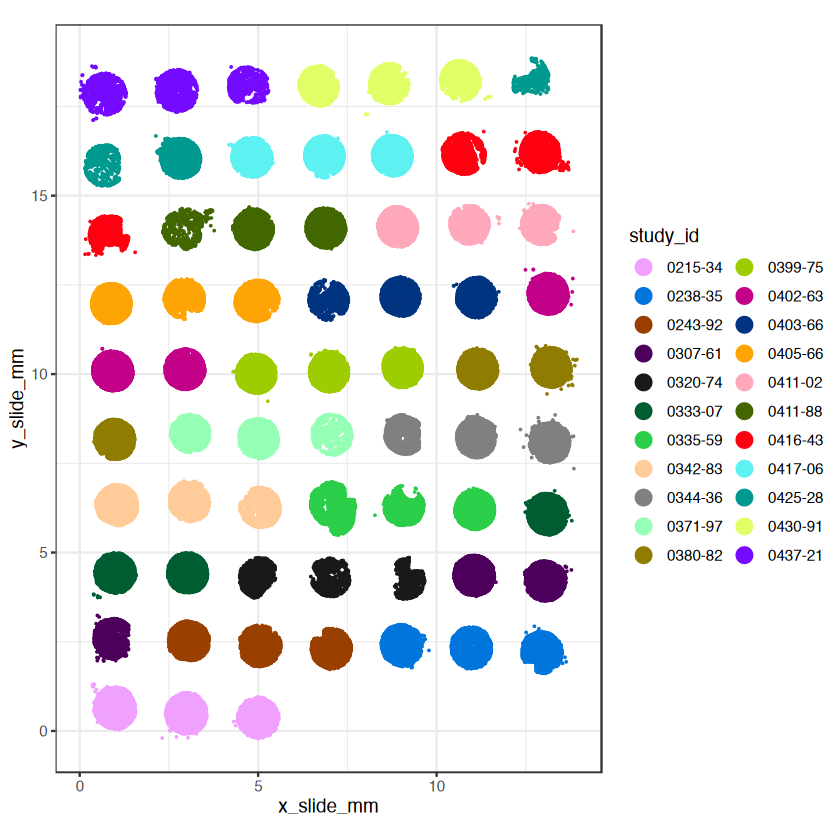

In [84]:
# Visualize the data
xyplot(study_id_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [85]:
unique(seu@meta.data[[study_id_col]])
unique(seu@meta.data[[region_col]])

[1] "0411-88" "0405-66" "0402-63" "0425-28" "0371-97" "0342-83" "0333-07"
 [8] "0243-92" "0215-34" "0437-21" "0416-43" "0417-06" "0399-75" "0320-74"
[15] "0430-91" "0403-66" "0335-59" "0411-02" "0344-36" "0238-35" "0380-82"
[22] "0307-61"

[1] 18_F8  18_F7  18_F6  18_G9  18_F5  18_F4  18_F3  18_F2  18_F1  18_E10
[11] 18_G8  18_E9  18_E8  18_E7  18_E6  18_E5  18_G10 18_E4  18_E3  18_E2 
[21] 18_E1  18_D10 18_D9  18_G7  18_D8  18_D7  18_D6  18_D5  18_D4  18_D3 
[31] 18_D2  18_C10 18_C9  18_C8  18_G6  18_C7  18_C6  18_C5  18_C4  18_C3 
[41] 18_C2  18_B10 18_B9  18_B8  18_B7  18_G5  18_B6  18_B5  18_B4  18_B3 
[51] 18_B2  18_A10 18_A9  18_A8  18_A7  18_A6  18_A5  18_G4  18_A4  18_A3 
[61] 18_A2  18_G3  18_G2  18_G1  18_F10 18_F9 
66 Levels: 18_A2 18_A3 18_A4 18_A5 18_A6 18_A7 18_A8 18_A9 18_A10 ... 18_G10

Setting

In [86]:
if (subset) {

    # Filter for one patient only
    seu <- subset(seu, subset = study_id %in% c("0238-35"))

    # Filter for one region only
    # seu <- subset(seu, subset = region %in% c("18_C9"))

}

# Drop unused levels
seu@meta.data[[region_col]] <- droplevels(seu@meta.data[[region_col]])

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


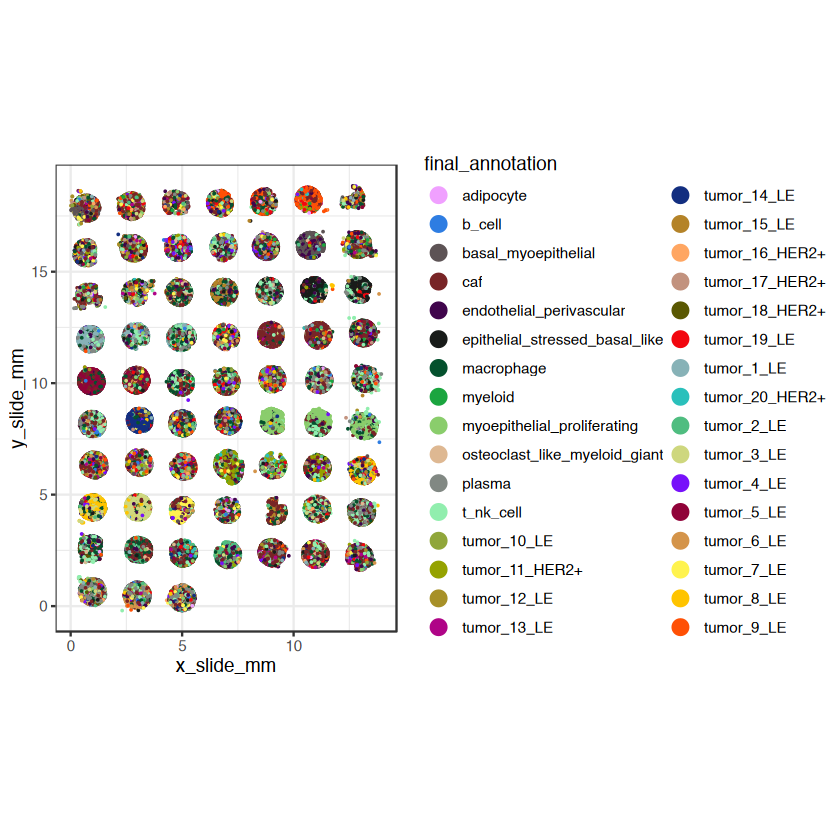

In [87]:
# Visualize the data
xyplot(annotation_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [88]:
nrow(seu)
ncol(seu)

[1] 6175

[1] 189704

Prepare the data

In [89]:
# Counts Data
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)
neg_counts <- Matrix::t(seu[["negprobes"]]$counts)
metadata <- seu@meta.data # row-aligned with the counts matrix
metadata$neg_total_counts <- Matrix::rowSums(neg_counts)
metadata$negmean <- Matrix::rowMeans(neg_counts)
xy <- as.matrix(metadata[, c(sdimx_col, sdimy_col)])

# Quick check: are the cell IDs of 'counts', 'metadata', and 'xy' in the same order?
all(rownames(counts) == rownames(metadata))
all(rownames(counts) == rownames(xy))

## normalize counts matrix using efficient sparse matrix calls:
scale_row <- mean(metadata$nCount_RNA) / metadata$nCount_RNA
norm <- counts
norm@x <- norm@x * scale_row[norm@i + 1L]

[1] TRUE

[1] TRUE

## Extract Adjacency Matrix

In [90]:
# The NN adjacency matrix was stored back into the Seurat object as a Seurat Graph.
# Graph objects inherit from dgCMatrix so they can be subsetted and used directly.
adjacency_matrix <- seu[[graph_slot]]

# Align rows/cols to the cells present in the counts matrix (handles any subset)
adjacency_matrix <- adjacency_matrix[rownames(counts), rownames(counts)]

cat("Adjacency matrix dimensions:", dim(adjacency_matrix), "\n")
cat("Non-zero entries:", Matrix::nnzero(adjacency_matrix), "\n")

Adjacency matrix dimensions: 189704 189704 
Non-zero entries: 9521936 


## Run HieraType — Levels 1 & 2 (Broad + Immune Subtyping)

In [ ]:
# Build the two-level pipeline:
#   L1: classify every cell as immune vs. non-immune
#   L2: sub-classify immune cells (B, T, macrophage, DC, neutrophil, …)
pipeline_io_rna <- HieraType::make_pipeline(
    markerslists = list(
        "l1" = HieraType::markerslist_l1,
        "l2" = HieraType::markerslist_immune
    ),
    priors          = list("l2" = "l1"),
    priors_category = list("l2" = "immune")
)

# Cache path – flip to FALSE after first run to reload from disk instead
ht_l1l2_file <- file.path(full_out_dir, paste0("hieratype_l1l2_", run_tag, ".RDS"))

if (TRUE) {
    message("Running HieraType L1 + L2 ...")
    hieratyperes <- HieraType::run_pipeline(
        pipeline         = pipeline_io_rna,
        counts_matrix    = counts,
        totalcounts      = metadata$nCount_RNA,
        adjacency_matrix = adjacency_matrix[rownames(counts), rownames(counts)]
    )
    saveRDS(hieratyperes, ht_l1l2_file)
    message("Done. Saved to: ", ht_l1l2_file)
} else {
    message("Loading cached HieraType L1+L2 results from: ", ht_l1l2_file)
    hieratyperes <- readRDS(ht_l1l2_file)
}

## Run HieraType — Level 3 (T Cell Fine Typing)

In [ ]:
# Identify T cells from the L1 probability table
# (L1 labels immune cells; T cells carry the "tcell" tag in celltype_granular)
tcell_ids <- hieratyperes$post_probs$l1[celltype_granular=="tcell"][["cell_ID"]]

cat("T cells identified at L1:", length(tcell_ids), "\n")

# Cache path
ht_l3_file <- file.path(full_out_dir, paste0("hieratype_l3_tcell_", run_tag, ".RDS"))

if (TRUE) {
    message("Running HieraType L3 (T cell fine typing) on ", length(tcell_ids), " cells ...")
    hieratyperes_tcell <- HieraType::run_pipeline(
        pipeline              = HieraType::pipeline_tcell,
        counts_matrix         = counts[tcell_ids, , drop = FALSE],
        totalcounts           = metadata[tcell_ids, "nCount_RNA"],
        adjacency_matrix      = adjacency_matrix[tcell_ids, tcell_ids],
        celltype_call_threshold = 0.5
    )
    saveRDS(hieratyperes_tcell, ht_l3_file)
    message("Done. Saved to: ", ht_l3_file)
} else {
    message("Loading cached HieraType L3 results from: ", ht_l3_file)
    hieratyperes_tcell <- readRDS(ht_l3_file)
}

## Unify HieraType Results

In [93]:
# unify calls
htclust <- hieratyperes$post_probs$l1$celltype_granular
names(htclust) <- hieratyperes$post_probs$l1$cell_ID
htclust[hieratyperes_tcell$post_probs$tmajor$cell_ID] <- hieratyperes_tcell$post_probs$tmajor$celltype_granular
htclust <- htclust[match(rownames(metadata), names(htclust))]
metadata$hieratype_call <- htclust

cat("HieraType call distribution:\n")
print(sort(table(metadata$hieratype_call), decreasing = TRUE))

HieraType call distribution:

   epithelial    fibroblast smooth_muscle   endothelial    macrophage 
        72661         24475         16344         14566         11823 
     monocyte        plasma         bcell    neutrophil       cd8_tem 
        10454          9793          3429          3095          2835 
    dendritic      cd4_treg cd8_cytotoxic            nk          mast 
         2574          2484          2315          1886          1833 
    cd8_naive cd8_exhausted       cd4_tem     cd4_naive       cd4_tcm 
         1294          1254          1191          1127          1104 
      cd4_th2      cd4_th17       cd4_th1       cd8_tcm 
          976           771           760           660 


## Merge HieraType with Louvain Clusters

In [ ]:
# Collect all labels that should be preserved after integration:
supervised_labels_keep <- unique(na.omit(metadata$hieratype_call))
cat("Supervised labels to keep (", length(supervised_labels_keep), "):\n")
print(sort(supervised_labels_keep))

# Integrate Louvain clusters with HieraType supervised calls.
# - dissolve_smallcluster_if_overwritten_prop_greaterthan:
#     if >90 % (or >50 %) of a cluster is overwritten by a supervised label,
#     dissolve the cluster and keep the supervised label.
# - and_dissolve_smallcluster_if_finalcluster_prop_lessthan:
#     additionally dissolve clusters that are <5 % (or <1 %) of the dataset.
ht_integrated_file <- file.path(full_out_dir, paste0("hieratype_integrated_", run_tag, ".RDS"))

if (TRUE) {
    message("Running celltype_label_integration ...")
    integrated_labels <- HieraType::celltype_label_integration(
        metadata             = metadata,
        adjacency_mat        = adjacency_matrix,
        cellid_colname       = cell_id_col,
        unsupervised_colname = cluster_col,
        supervised_colname   = "hieratype_call",
        supervised_labels_keep = supervised_labels_keep,
        dissolve_smallcluster_if_overwritten_prop_greaterthan   = c(0.9, 0.5),
        and_dissolve_smallcluster_if_finalcluster_prop_lessthan = c(0.05, 0.01)
    )
    saveRDS(integrated_labels, ht_integrated_file)
    message("Done. Saved to: ", ht_integrated_file)
} else {
    message("Loading cached integrated labels from: ", ht_integrated_file)
    integrated_labels <- readRDS(ht_integrated_file)
}

celltype <- metadata$celltype <- integrated_labels$celltype[match(metadata[[cell_id_col]], integrated_labels[[cell_id_col]])]

cat("\nFinal celltype distribution:\n")
print(sort(table(metadata$celltype), decreasing = TRUE))

## Save Outputs

In [ ]:
# Save updated metadata as RDS (dynamic name based on run_tag)
meta_out_file <- file.path(full_out_dir, paste0("metadata_with_celltypes_", run_tag, ".RDS"))
saveRDS(metadata, meta_out_file)
message("Metadata saved to: ", meta_out_file)

# Add new columns back to the Seurat object and save
# (Seurat file name is fixed — not parameterised by run_tag)
seu$hieratype_call <- metadata[colnames(seu), "hieratype_call"]
seu$celltype       <- metadata[colnames(seu), "celltype"]

seu_out_file <- file.path(out_dir_seu, sub("\\.RDS$", "_hieratype.RDS", basename(seu_file_path)))
saveRDS(seu, seu_out_file)
message("Seurat object saved to: ", seu_out_file)

## Marker Heatmaps

### Heatmap 1 — Canonical Index Markers

In [ ]:
# Pull index-marker gene vectors from both pipelines
indexmarkers <- unique(c(
  unlist(pipeline_io_rna$markerslists$l2)[grepl("index_marker", names(unlist(pipeline_io_rna$markerslists$l2)))],
  unlist(HieraType::pipeline_tcell)[grepl("index_marker", names(unlist(HieraType::pipeline_tcell)))]
))
cat("Index markers found:", length(indexmarkers), "\n")

# Restrict to genes present in the norm matrix
indexmarkers <- indexmarkers[indexmarkers %in% colnames(norm)]
cat("Index markers in norm matrix:", length(indexmarkers), "\n")

# Compute per-celltype fold-change metrics on the index-marker subset
fc_idx <- HieraType::clusterwise_foldchange_metrics(
  normed         = Matrix::t(norm[, indexmarkers]),
  metadata       = data.frame("cell_ID" = names(htclust), "hieratype_call" = htclust),
  cluster_column = "hieratype_call"
)

# Save heatmap
hm1_file <- file.path(full_out_dir, paste0("heatmap_index_markers_", run_tag, ".pdf"))
pdf(hm1_file, width = 14, height = 10)
HieraType::marker_heatmap(fc_idx)
dev.off()
message("Index-marker heatmap saved to: ", hm1_file)

### Heatmap 2 — Data-Driven Markers (All Genes)

In [ ]:
# Use the full norm matrix (all genes) to let HieraType pick the most discriminative markers per cell type.
fc_all <- HieraType::clusterwise_foldchange_metrics(
    normed         = Matrix::t(norm),
    metadata       = data.frame("cell_ID" = names(htclust), "hieratype_call" = htclust),
    cluster_column = "hieratype_call"
)

# Save heatmap
hm2_file <- file.path(full_out_dir, paste0("heatmap_datadriven_markers_", run_tag, ".pdf"))
pdf(hm2_file, width = 14, height = 10)
HieraType::marker_heatmap(fc_all)
dev.off()
message("Data-driven marker heatmap saved to: ", hm2_file)

## Session Info

In [101]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-apple-darwin13.4.0
Running under: macOS Tahoe 26.2

Matrix products: default
BLAS/LAPACK: /Users/fs2829/miniforge3/envs/COSMX_RNA_env_proj_ADANA/lib/libopenblasp-r0.3.30.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] mvtnorm_1.3-3         HieraType_1.0.3       circlize_0.4.17      
 [4] viridis_0.6.5         viridisLite_0.4.2     ComplexHeatmap_2.26.0
 [7] pheatmap_1.0.13       InSituCor_0.0.0.9000  fs_1.6.6             
[10] scPearsonPCA_0.0.1.0  tibble_3.3.1          gtools_3.9.5         
[13] cluster_2.1.8.1       ggrastr_1.0.2         RColorBrewer_1.1-3   
[16] pals_1.10             ggrepel_0.9.6         harmony_1.2.4        
[19] Rcpp_1.1.1            Matrix_1.7-4          data.table_1.17.8    
[22] patchwork_1.3.2       g